Questão 01: Como vimos em aula, é possível usar Poisson para modelar uma pesca. Suponha que um pescador pesca por 10 horas com taxa de chegada de peixes λ = 1/h. Agora, suponha também que, após cada peixe pescado, o pescador interrompe a pesca e gasta meia hora limpando o peixe antes de retomar a pescaria. 

 a) Plote um exemplo dessa pesca. 
    
 b) Usando Monte Carlo, gere um gráfico da probabilidade de cada quantidade de peixes pescados (isto é, um gráfico de Nº de Peixes X Probabilidade, que mostre qual a probabilidade de a pescaria resultar em 0, 1, 2, 3,... peixes).

 c) Analisando os resultados anteriores, essa pescaria continua sendo bem modelada como um processo de Poisson? Justifique.


Letra A:

[0, 1.1879636192819802, 3.369964282688607, 3.908348388804737, 5.814713832179266, 6.637213114007064, 7.308354829874529, 8.08162989339846, 9.779804135593475, 11.176197369561118]


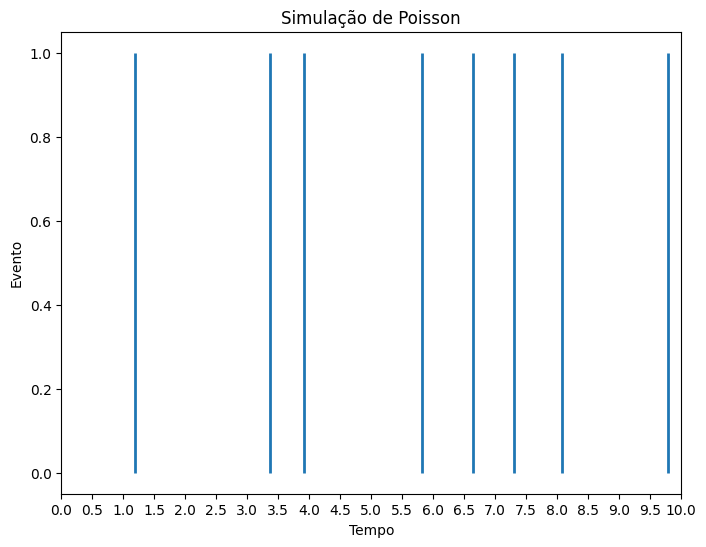

In [29]:
import numpy as np
from numpy import random
import matplotlib.pyplot as plt

tempo = [0]

lamb = 1

while tempo[-1] < 10:
    tempo.append(tempo[-1] + random.exponential(1/lamb) + 0.5) #tempo para cada evento ocorrer + meia hora de interrupcao
print(tempo)

tempo = tempo[1:-1]

plt.figure(figsize=(8, 6))
plt.xticks(np.arange(11, step=0.5))
plt.vlines(tempo, 0, 1, linewidth=2)
plt.xlim(0, 10)
plt.xlabel('Tempo')
plt.ylabel('Evento')
plt.title('Simulação de Poisson')
plt.show()

Letra B:

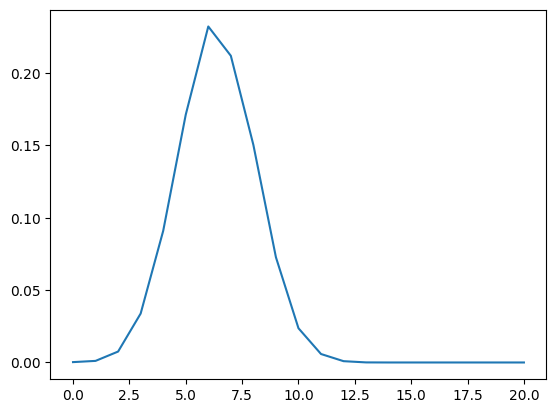

In [4]:
peixes = 21

lamb = 1

sucessos_totais = []

simulacoes = 20000

for j in range(peixes):
    
    sucessos = []
    
    #100 simulacoes para cada quantidade j de peixes
    for i in range(simulacoes):
        tempo = [0]
        
        while tempo[-1] < 10:
            tempo.append(tempo[-1] + random.exponential(1/lamb) + 0.5) #tempo para cada evento ocorrer + meia hora de interrupcao
        
        #print(j,tempo)
        
        if (len(tempo) - 2) == j: #sempre ignora o primeiro e o ultimo elemento do vetor de tempos
            sucessos.append(1)
        else:
            sucessos.append(0)
    
    sucessos_totais.append(sum(sucessos)/simulacoes)

plt.plot(range(21),sucessos_totais)
plt.show()

Letra C: Sim, pois os resultados evidenciam como os eventos se comportam que nem uma distribuição de Poisson

Questão 02: Considere o exercício das 2 máquinas (exercício 4, slides de aula de cadeia de Markov Contínua). Simule e plote os resultados do tempo que as máquinas passam em cada estado para vários pares de valores de (λ, μ). Analise e comente os resultados.

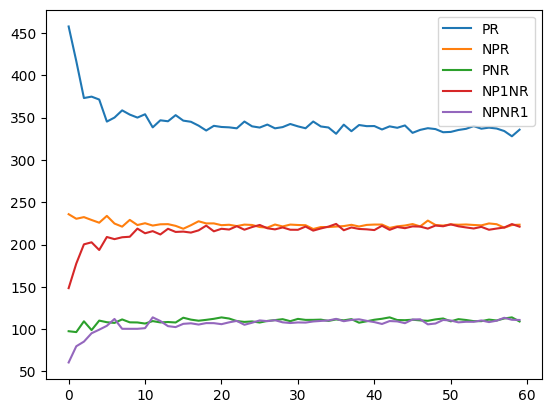

In [2]:
t_inicial = 0
t_final = 1000

iterations = 60

tempos_totais = {}

tempos_totais['PR'] = []
tempos_totais['NPR'] = []
tempos_totais['PNR'] = []
tempos_totais['NP1NR'] = []
tempos_totais['NPNR1'] = []

for i in range(iterations):

    mi = i + 1.5

    lamb = i + 1

    #5 estados = PR, NPR, PNR, NP1NR, NPNR1

    transition_rates = np.array([[0.0, lamb, 0.0, 0.0, 0.0],
                                [mi, 0.0, 0.0, lamb, 0.0],
                                [mi, 0.0, 0.0, 0.0, lamb],
                                [0.0, 0.0, mi, 0.0, 0.0],
                                [0.0, mi, 0.0, 0.0, 0.0]])

    estado = 0
    tempo_estados = [0,0,0,0,0]

    while sum(tempo_estados) < t_final:
        tempos = []
        for tr in transition_rates[estado]:
            if(tr == 0):
                tempos.append(float('inf'))
            else:
                tempos.append(np.random.exponential(1/tr))
        tempo_estados[estado] += min(tempos)
        estado = tempos.index(min(tempos))

    tempos_totais['PR'].append(tempo_estados[0])
    tempos_totais['NPR'].append(tempo_estados[1])
    tempos_totais['PNR'].append(tempo_estados[2])
    tempos_totais['NP1NR'].append(tempo_estados[3])
    tempos_totais['NPNR1'].append(tempo_estados[4])

for i,j in tempos_totais.items():
    plt.plot(range(iterations),j,label = i)

plt.legend()
plt.show()

Questão 03: Considere o exercício do Spa (exercício 5, slides de aula de cadeia de Markov Contínua).

a) Considerando μ1 = μ2 = 1, simule o problema e plote o gráfico do número médio de pessoas no sistema (L) pela taxa de chegada (λ).

b) Fixando a taxa de chegada em λ = 0.8, simule o problema e plote o gráfico do número médio de pessoas no sistema (L) e o tempo de espera (W) pelo tamanho permitido da fila de espera (E). Considere que segundo o enunciado original, a fila de espera do Spa tem tamanho 0, mas que agora é possível que haja pessoas no Spa aguardando serviço.

Letra A)

Text(0, 0.5, 'LS')

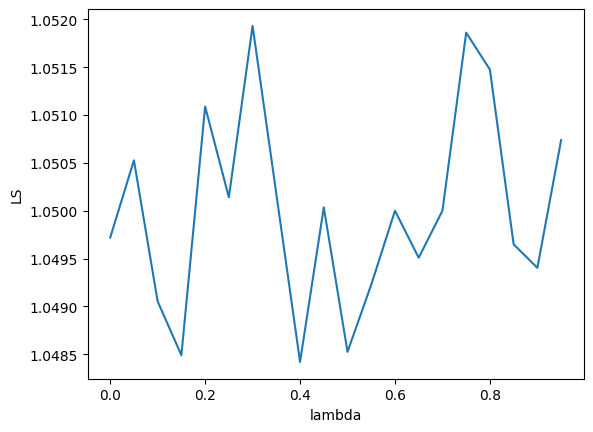

In [12]:
import numpy as np
import matplotlib.pyplot as plt

mu = 1
Tmax = 100000
iterations = 20

LS = []

for i in range(iterations):
    lamb = 1/iterations

    Ls0 = 0
    Ls = [Ls0]
    T = [0]
    massagem = 0
    acupuntura = 0
    
    while T[-1] <  Tmax:
        if Ls[-1] == 0:
            massagem = 1
            
        else:
            if np.random.random() < (lamb/(lamb+mu)):#massagem em atendimento
                massagem = 1
            else:#massagem liberou
                if acupuntura == 0:#não tem ninguém na acupuntura
                    massagem = 0
                    acupuntura = 1 #insere a pessoa que liberou na massagem para a acupuntura
                else:
                    if np.random.random() < (lamb/(lamb+mu)):#acupuntura em atendimento
                        acupuntura = 1
                    else: #acupuntura liberou
                        #pessoa livre da massagem sai e vai para acupuntura
                        massagem = 0
                        acupuntura = 1
        
        Ls.append(massagem + acupuntura)
        
        T.append(T[-1] + intervalo)
    
    LS.append(np.mean(Ls))

plt.plot(np.arange(0,1,1/iterations),LS)

plt.xlabel("lambda")
plt.ylabel("LS")


Letra B)

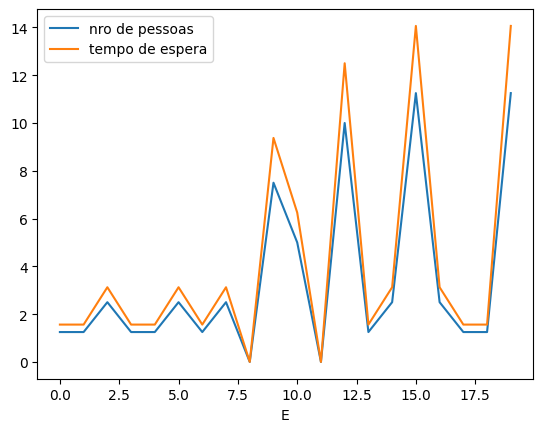

In [1]:
import numpy as np
import matplotlib.pyplot as plt

lamb = 0.8
mu = 1

pessoas_sist = []

for E in range(20):

    L0 = 0
    L = [L0]
    T = [0]
    Tmax = 100000
    intervalo = 0
    tz = 0

    while T[-1] <  Tmax:
        if L[-1] == 0:
            intervalo = np.random.exponential(1/lamb)
            tz += intervalo
            L.append(1)
        else:
            intervalo = np.random.exponential(1/(lamb+mu))
            if np.random.random() < (lamb/(lamb+mu)):
                if (L[-1] + 1) <= E : L.append(L[-1] + 1) #só entra gente na fila se houver espaço!
            else:
                L.append(L[-1] - 1)
        T.append(T[-1] + intervalo)
    
    #temos o numero de pessoas na fila
    #para converter para numero de pessoas no sistema, só multiplicar por: mi/lamb
    
    pessoas_sist.append((L[-1] * mu)/lamb)

pessoas_sist = np.array(pessoas_sist)

plt.plot(range(20),pessoas_sist,label = "nro de pessoas")

plt.plot(range(20),pessoas_sist/lamb, label = "tempo de espera")
plt.xlabel("E")

plt.legend(loc = "upper left")


Questão 04:Considere uma fila de banco M/M/1 com taxa de chegada λ = 1 e taxa de serviço μ = 1.2. Considere ainda que cada cliente que chega tem uma probabilidade P de ser um cliente Preferencial, e que o cliente preferencial passa na frente de todos os clientes regulares.

 a) Simule e plote o gráfico do tempo médio de espera W por alguns valores de P (inclua P=0).
 
 b) Simule e plote um boxplot (também chamado de box & whisker plot) do tempo de espera por alguns valores de P (inclua P=0).

Letra A) e B)


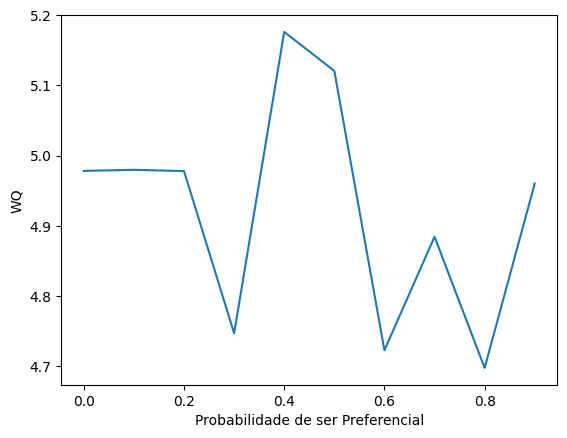

{'whiskers': [<matplotlib.lines.Line2D at 0x2187eefd910>,
 'caps': [<matplotlib.lines.Line2D at 0x2187eefe2d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2187eefd0d0>],
 'medians': [<matplotlib.lines.Line2D at 0x2187ef02f60>],
 'fliers': [<matplotlib.lines.Line2D at 0x2187ef00800>],
 'means': []}

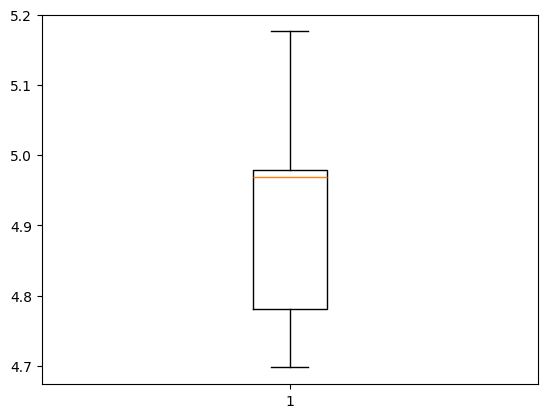

In [22]:
import numpy as np
import matplotlib.pyplot as plt

#A

lamb = 1
mu = 1.2
exps = 1000
Tmax = 100000
intervalo = 0
probs = []
WQ = []

for i in range(10):
    prob = i/10
    tempos_chegada = []
    L0 = 0
    L = [L0]
    T = [0]
    tz = 0
    esperas = []
    
    while T[-1] <  Tmax:
        if tempos_chegada == []:
            intervalo = np.random.exponential(1/lamb)
            tz += intervalo
            
            tempos_chegada.append(T[-1]+intervalo)
        else:
            intervalo = np.random.exponential(1/(lamb+mu))
            
            if np.random.random() < (lamb/(lamb+mu)):
            
                if np.random.choice([0,1],p=[prob,1-prob]) == 0:
                
                    tempos_chegada.insert(0,T[-1]+intervalo)
                else:
                    tempos_chegada.append(T[-1]+intervalo)
            else:
                
                esperas.append(T[-1]+intervalo - tempos_chegada[0])
                tempos_chegada.pop(0)
        
        T.append(T[-1] + intervalo)
    WQ.append(np.mean(esperas))

plt.plot(np.arange(0,1,1/10),WQ)
plt.xlabel('Probabilidade de ser Preferencial')
plt.ylabel('WQ')
plt.show()

#B
plt.boxplot(WQ)

Questão 05) Compare o tempo de espera (W) de 2 filas M/M/1 independentes com taxa de chegada λ = 1  cada uma e de 1 fila única M/M/2 com taxa de chegada λ = 2. Calcule o tempo médio que um atendente fica ocioso em cada caso. Assuma a mesma taxa de serviço para todos os atendentes.

In [21]:
import numpy as np
import matplotlib.pyplot as plt

#2 filas M/M/1

lamb = 1
mu = 1

tz2MM1 = []

for i in range(5):
    
    L0 = 0
    L = [L0]
    T = [0]
    Tmax = 100000
    intervalo = 0
    tz1 = 0
    tz2 = 0

    while T[-1] <  Tmax:
        if L[-1] == 0:
            intervalo = np.random.exponential(1/lamb)
            tz1 += intervalo
            L.append(1)
        else:
            intervalo = np.random.exponential(1/(lamb+mu))
            if np.random.random() < (lamb/(lamb+mu)):
                L.append(L[-1] + 1)
            else:
                L.append(L[-1] - 1)
        T.append(T[-1] + intervalo)
    
    tz1 = tz1/Tmax
    
    L0 = 0
    L = [L0]
    T = [0]
    
    while T[-1] <  Tmax:
        if L[-1] == 0:
            intervalo = np.random.exponential(1/lamb)
            tz2 += intervalo
            L.append(1)
        else:
            intervalo = np.random.exponential(1/(lamb+mu))
            if np.random.random() < (lamb/(lamb+mu)):
                L.append(L[-1] + 1)
            else:
                L.append(L[-1] - 1)
        T.append(T[-1] + intervalo)
    
    tz2 = tz2/Tmax
    
    tz2MM1.append((tz1 + tz2)/2)#média da taxa de tempo ocioso das duas filaz M/M/1 independentes

#1 fila M/M/2

lamb = 2
mu = 2

tz2MM2 = []

for i in range(5):

    L0 = 0
    L = [L0]
    T = [0]
    Tmax = 100000
    intervalo = 0
    tz1 = 0
    tz2 = 0

    while T[-1] <  Tmax:
        if L[-1] == 0:
            intervalo = np.random.exponential(1/lamb)
            tz1 += intervalo
            tz2 += intervalo
            L.append(1)
        else:
            intervalo = np.random.exponential(1/(lamb+mu))
            
            if np.random.random() < (lamb/(lamb+mu)):#primeiro atendente tá atendendo
                
                if np.random.random() < (lamb/(lamb+mu)):#segundo atendente tá atendendo
                    L.append(L[-1] + 1)
                else:#segundo atendente ocioso
                    if L[-1] > 0: L.append(L[-1] - 1) #atende outro na fila
                    else: tz2 += intervalo #nao tem ninguem pra atender
                
            else:#primeiro atentende ocioso
                if L[-1] > 0: L.append(L[-1] - 1) #atende outro na fila
                else: tz1 += intervalo #nao tem ninguem pra atender
                
                if np.random.random() < (lamb/(lamb+mu)):#segundo atendente tá atendendo
                    L.append(L[-1] + 1)
                else:#segundo atendente ocioso
                    if L[-1] > 0: L.append(L[-1] - 1) #atende outro na fila
                    else: tz2 += intervalo #nao tem ninguem pra atender
                
        T.append(T[-1] + intervalo)
    
    tz1 = tz1/Tmax
    tz2 = tz2/Tmax
    
    tz2MM2.append((tz1 + tz2)/2)#média da taxa de tempo ocioso da fila M/M/2 independentes

print("no caso de 2 filas M/M/1:",np.mean(tz2MM1)," no caso de 1 fila M/M/2:",np.mean(tz2MM2),",\n mostrando que uma fila M/M/2 tem mais eficiência que duas filas M/M/1")

no caso de 2 filas M/M/1: 0.0036820244439539685  no caso de 1 fila M/M/2: 0.4584296386916596 ,
 mostrando que uma fila M/M/2 tem mais eficiência que uma fila M/M/1


Questao 06: Considere a rede de filas M/M/1 da figura abaixo, representando um trecho de avenidas de  uma grande cidade, com cada fila representando um cruzamento congestionado. Considere os valores: λ1 = 10, λ2 = 14, μA = 15, μB = 30, μC = 24, μD = 20, μE = 6 (dados em veículos por minuto). A prefeitura deseja realizar obras para melhorar o fluxo de veículos em um dos 5 cruzamentos (isto é, aumentar a taxa de serviço), visando reduzir o tempo médio de espera (W) na rede. Mostre por simulação e discuta qual o cruzamento seria o melhor candidato para a melhoria.

In [35]:
lambA = 10
lambC = 0.75*lambA + 14
lambB = (0.25*lambA + 0.7*lambC)/0.7
lambD = lambB
lambE = 0.3*lambC

mua = 15
mub = 30
muc = 24
mud = 20
mue = 6

WQA = []
WQB = []
WQC = []
WQD = []
WQE = []

CA = []
EA = []
CB = []
EB = []
CC = []
EC = []
CD = []
ED = []
CE = []
EE = []

Tmax = 10000
T = [0]

while T[-1] <  Tmax:
    
    #caso A
    if CA == []:
        intervalo = np.random.exponential(1/lambA)
        CA.append(T[-1] + intervalo)
    else:
        intervalo = np.random.exponential(1/lambA)
        if np.random.random() < (lambA/(lambA+mua)): # A ocupado
            CA.append(T[-1] + intervalo)
        else:#sai da fila de CA
            EA.append(T[-1] + intervalo - CA[0])
            CA.pop(0)
    
    T.append(T[-1] + intervalo)

T = [0]
while T[-1] <  Tmax:
    #caso B
    if CB == []:
        intervalo = np.random.exponential(1/lambB)
        CB.append(T[-1] + intervalo)
    else:
        intervalo = np.random.exponential(1/lambB)
        if np.random.random() < (lambB/(lambB+mub)): # A ocupado
            CB.append(T[-1] + intervalo)
        else:#sai da fila de CA
            EB.append(T[-1] + intervalo - CB[0])
            CB.pop(0)
    
    T.append(T[-1] + intervalo)

T = [0]
while T[-1] <  Tmax:
    #caso C
    if CC == []:
        intervalo = np.random.exponential(1/lambC)
        CC.append(T[-1] + intervalo)
    else:
        intervalo = np.random.exponential(1/lambC)
        if np.random.random() < (lambC/(lambC+muc)): # A ocupado
            CC.append(T[-1] + intervalo)
        else:#sai da fila de CA
            EC.append(T[-1] + intervalo - CC[0])
            CC.pop(0)
    
    T.append(T[-1] + intervalo)

T = [0]
while T[-1] <  Tmax:
    #caso D
    if CD == []:
        intervalo = np.random.exponential(1/lambD)
        CD.append(T[-1] + intervalo)
    else:
        intervalo = np.random.exponential(1/lambD)
        if np.random.random() < (lambD/(lambD+mud)): # A ocupado
            CD.append(T[-1] + intervalo)
        else:#sai da fila de CA
            ED.append(T[-1] + intervalo - CD[0])
            CD.pop(0)
    
    T.append(T[-1] + intervalo)

T = [0]
while T[-1] <  Tmax:
    #caso E
    if CE == []:
        intervalo = np.random.exponential(1/lambE)
        CE.append(T[-1] + intervalo)
    else:
        intervalo = np.random.exponential(1/lambE)
        if np.random.random() < (lambE/(lambE+mue)): # A ocupado
            CE.append(T[-1] + intervalo)
        else:#sai da fila de CA
            EE.append(T[-1] + intervalo - CE[0])
            CE.pop(0)
    
    T.append(T[-1] + intervalo)

WQA.append(np.mean(EA))
WQB.append(np.mean(EB))
WQC.append(np.mean(EC))
WQD.append(np.mean(ED))
WQE.append(np.mean(EE))

print("tempo espera A:", np.mean(WQA),"\ntempo espera B:",np.mean(WQB),"\ntempo espera C:", np.mean(WQC),"\ntempo espera D:",np.mean(WQD),"\ntempo espera E:", np.mean(WQE))

print("tanto E quanto D são candidatos a melhoria, com D em ênfase")

tempo espera A: 0.4873246593183018 
tempo espera B: 0.4381047024115866 
tempo espera C: 0.9295107733053054 
tempo espera D: 1009.7335316177804 
tempo espera E: 264.59014082984794
tanto E quanto D são candidatos a melhoria, com D em ênfase
